# RapidSegment vs. Decision Tree — General Comparison

A head-to-head comparison of **RapidSegment** and the bare iterative **Decision Tree** segmenter on *any* dataset you point it at.

| Method | What it does |
| --- | --- |
| **RapidSegment** | Apriori-style combinatorial rule search (1/2/3-way) over IV-ranked, OptBinning-binned features; hierarchical greedy extraction. Tuned here for event capture: `sort_priority="lift_events_rate"`, `max_feature_reuse=5`, `min_lift=1.0`. |
| **Decision Tree (bare)** | One `DecisionTreeClassifier` fit per iteration; picks the root-to-leaf path with maximum event capture, removes matched rows, repeats. Default floor `min_lift=1.3`. |

**Configure the dataset and knobs in the next cell, then run all cells.**

Use `IGNORE_COLUMNS` to drop IDs / PII / leakage features so both models see the same feature space.

In [1]:
import logging
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable

# Make sure the sibling DT script is importable regardless of the notebook's cwd.
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "Examples" else Path.cwd() / "Examples"))

from rapidsegment import StrategicSegmentBuilder, UniversalDataLoader
from decision_tree_segmentation import run_decision_tree_segmentation

logging.getLogger("StrategicEngine").setLevel(logging.WARNING)
logging.getLogger("StrategicEngine.DataLoader").setLevel(logging.WARNING)

%matplotlib inline

# ---------------------------------------------------------------------------
# USER CONFIG — edit these
# ---------------------------------------------------------------------------
DATA_PATH = Path(r"D:\RapidSegment\Examples\Term_Deposit_Sub\bank_train.csv")   # csv / parquet / arrow / feather / xlsx
TARGET = "y"                            # None = auto-detect from common names
POSITIVE = "yes"                           # None = auto if already 0/1 or boolean
IGNORE_COLUMNS = ['id','CustomerId','Surname']                          # e.g. ["id", "customer_id", "RowNumber"]

# Shared hard constraints
MIN_SAMPLE_SIZE = 1000
MIN_EVENTS = 100
MAX_SEGMENTS = 12

# RapidSegment tuning knobs
RS_SORT_PRIORITY = "response_events_lift"   # lift first, then events
RS_FEATURE_REUSE = 5
RS_MIN_LIFT = 1.20
RS_TOP_N_VARS = 15

# Decision-tree knobs (original bare config by default)
DT_MIN_LIFT = 1.20
DT_MIN_SAMPLE_SIZE = 1000
DT_MIN_EVENTS = 100

print("Setup complete.")
print(f"  DATA_PATH       = {DATA_PATH}")
print(f"  TARGET          = {TARGET}")
print(f"  POSITIVE        = {POSITIVE}")
print(f"  IGNORE_COLUMNS  = {IGNORE_COLUMNS}")

Setup complete.
  DATA_PATH       = D:\RapidSegment\Examples\Term_Deposit_Sub\bank_train.csv
  TARGET          = y
  POSITIVE        = yes
  IGNORE_COLUMNS  = ['id', 'CustomerId', 'Surname']


## 1. Load and prepare the data

In [2]:
def load_dataframe(path: Path) -> pd.DataFrame:
    ext = path.suffix.lower()
    try:
        arrow_table = UniversalDataLoader(file_path=str(path)).load()
        return arrow_table.to_pandas()
    except Exception as exc:
        print(f"UniversalDataLoader failed ({exc}); falling back to pandas.")
    if ext == ".csv":
        return pd.read_csv(path, sep=None, engine="python")
    if ext in (".parquet", ".pq"):
        return pd.read_parquet(path)
    if ext in (".arrow", ".feather"):
        return pd.read_feather(path)
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file format: '{ext}'.")


PREFERRED_TARGETS = [
    "target", "Target", "TARGET", "label", "Label", "y", "Y",
    "class", "Class", "CLASS", "response", "Response", "churn", "Churn",
    "exited", "Exited", "default", "Default", "survived", "Survived",
    "converted", "Converted",
]


def detect_target(frame: pd.DataFrame, explicit):
    if explicit:
        if explicit not in frame.columns:
            raise ValueError(f"Target column '{explicit}' not found. Available: {sorted(frame.columns)}")
        return explicit
    hits = [c for c in PREFERRED_TARGETS if c in frame.columns]
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        raise ValueError(f"Multiple likely targets {hits}; set TARGET explicitly.")
    raise ValueError(f"Could not auto-detect target. Available: {sorted(frame.columns)}")


def ensure_binary(frame: pd.DataFrame, target: str, positive):
    frame = frame.copy()
    if frame[target].isna().any():
        n_dropped = int(frame[target].isna().sum())
        print(f"Dropping {n_dropped:,} rows with null target.")
        frame = frame[frame[target].notna()]
    ser = frame[target]
    uniq = sorted(ser.unique(), key=lambda v: (str(v), v))

    if all(isinstance(v, bool) for v in uniq):
        frame[target] = ser.astype(int)
        return frame, "boolean mapped to 0/1 (True=1)"

    if all(
        isinstance(v, (int, float)) and not isinstance(v, bool)
        and float(v) in (0.0, 1.0)
        for v in uniq
    ):
        frame[target] = ser.astype(int)
        return frame, None

    if positive is None:
        raise ValueError(
            f"Target '{target}' is not binary 0/1. Classes: {uniq}. "
            "Set POSITIVE to the positive-class value."
        )
    if positive not in uniq:
        raise ValueError(f"POSITIVE={positive!r} is not a class of '{target}'. Classes: {uniq}")
    frame[target] = (ser == positive).astype(int)
    return frame, f"'{positive}' mapped to 1; everything else to 0"


def resolve_ignore_columns(frame, ignore_columns, target):
    if not ignore_columns:
        return []
    resolved, missing = [], []
    for col in ignore_columns:
        if col == target:
            print(f"Warning: ignore column '{col}' is the target — skipping.")
            continue
        if col not in frame.columns:
            missing.append(col)
            continue
        resolved.append(col)
    if missing:
        print(f"Warning: ignore columns not found (skipped): {missing}")
    if resolved:
        print(f"Ignoring columns: {resolved}")
    return resolved


frame = load_dataframe(DATA_PATH)
print(f"Loaded: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns")
print(f"Columns: {list(frame.columns)}")

target = detect_target(frame, TARGET)
frame, note = ensure_binary(frame, target, POSITIVE)
ignore_columns = resolve_ignore_columns(frame, IGNORE_COLUMNS, target)

total_events = int(frame[target].sum())
total_pop = int(frame.shape[0])
base_rate = total_events / total_pop * 100

print(f"Target : '{target}'")
print(f"Rows   : {total_pop:,}")
print(f"Events : {total_events:,}  (base response rate {base_rate:.2f}%)")
if note:
    print(f"Encoding: {note}")

Loaded: 40,689 rows x 17 columns
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Target : 'y'
Rows   : 40,689
Events : 4,760  (base response rate 11.70%)
Encoding: 'yes' mapped to 1; everything else to 0


## 2. RapidSegment (capture-tuned)

In [3]:
rs_builder = StrategicSegmentBuilder(
    target=target,
    min_sample_size=MIN_SAMPLE_SIZE,
    min_lift=RS_MIN_LIFT,
    min_events=MIN_EVENTS,
    top_n_vars=RS_TOP_N_VARS,
    max_segments=MAX_SEGMENTS,
    max_feature_reuse=RS_FEATURE_REUSE,
    sort_priority=RS_SORT_PRIORITY,
    ignore_features=list(ignore_columns) if ignore_columns else [],
    persist_db = True
)

t0 = time.time()
rs_segments = rs_builder.extract_segments(frame)
rs_coverage = rs_builder.evaluate_final_coverage(frame)
rs_elapsed = time.time() - t0
print(f"RapidSegment extracted {len(rs_segments)} segments "
      f"({rs_builder.stop_reason}, {rs_elapsed:.1f}s)")

RapidSegment extracted 9 segments (No candidate rules met the minimum grid thresholds (sample size / lift)., 21.2s)


In [4]:
rs_rows = []
for row in rs_coverage:
    if row["segment"] == 0:
        continue
    rs_rows.append({
        "segment_id": int(row["segment"]),
        "rule": rs_segments[int(row["segment"]) - 1]["rule_string"],
        "count": int(row["total_count"]),
        "events": int(row["target_events"]),
        "response_rate": float(row["response_rate"]),
        "lift": float(row["lift"]),
        "cum_evcap_pct": float(row["cumulative_event_capture"]),
        "cum_popcap_pct": float(row["cumulative_sample_capture"]),
    })

rs_table = PrettyTable()
rs_table.field_names = ["Seg", "Rule", "Count", "Events", "Resp %", "Lift",
                        "Cum EvCap %", "Cum PopCap %"]
rs_table.max_width["Rule"] = 66
for r in rs_rows:
    rs_table.add_row([r["segment_id"], r["rule"], f"{r['count']:,}", r["events"],
                      f"{r['response_rate']:.2f}", f"{r['lift']:.2f}",
                      f"{r['cum_evcap_pct']:.2f}", f"{r['cum_popcap_pct']:.2f}"])
print(rs_table)

+-----+--------------------------------------------------------------------+-------+--------+--------+------+-------------+--------------+
| Seg |                                Rule                                | Count | Events | Resp % | Lift | Cum EvCap % | Cum PopCap % |
+-----+--------------------------------------------------------------------+-------+--------+--------+------+-------------+--------------+
|  1  |  housing=[no] & pdays=[8.50, 197.50) & poutcome=[other, success]   | 1,163 |  701   | 60.28  | 5.15 |    14.73    |     2.86     |
|  2  |   contact=[cellular] & duration=[702.50, inf) & previous=(-inf,    | 1,254 |  723   | 57.66  | 4.93 |    29.92    |     5.94     |
|     |                               0.50)                                |       |        |        |      |             |              |
|  3  |                 duration=[613.50, inf) & loan=[no]                 | 1,643 |  707   | 43.03  | 3.68 |    44.77    |     9.98     |
|  4  |   contact=[cellular

## 3. Bare iterative decision tree

In [5]:
# Decision tree has no ignore_features param — drop columns so both models
# see the same feature space.
dt_frame = frame.drop(columns=list(ignore_columns)) if ignore_columns else frame

t0 = time.time()
dt_raw = run_decision_tree_segmentation(
    dt_frame,
    target_col=target,
    max_segments=MAX_SEGMENTS,
    min_sample_size=DT_MIN_SAMPLE_SIZE,
    min_events=DT_MIN_EVENTS,
    min_lift=DT_MIN_LIFT,
)
dt_elapsed = time.time() - t0
dt_meta = dt_raw[-1]
dt_segments = dt_raw[:-1]
print(f"Decision tree extracted {len(dt_segments)} segments "
      f"({dt_meta['_stop_reason']}, {dt_elapsed:.1f}s)")

Decision tree extracted 5 segments (No valid decision path found on the residual, 0.6s)


In [6]:
dt_rows = []
cum_ev = 0
cum_pop = 0
for seg in dt_segments:
    cum_ev += seg["events"]
    cum_pop += seg["count"]
    dt_rows.append({
        "segment_id": seg["segment_id"],
        "rule": seg["rule_string"],
        "count": seg["count"],
        "events": seg["events"],
        "response_rate": seg["response_rate"],
        "lift": seg["lift"],
        "cum_evcap_pct": cum_ev / total_events * 100,
        "cum_popcap_pct": cum_pop / total_pop * 100,
    })

dt_table = PrettyTable()
dt_table.field_names = ["Seg", "Rule", "Count", "Events", "Resp %", "Lift",
                        "Cum EvCap %", "Cum PopCap %"]
dt_table.max_width["Rule"] = 66
for r in dt_rows:
    dt_table.add_row([r["segment_id"], r["rule"], f"{r['count']:,}", r["events"],
                      f"{r['response_rate']:.2f}", f"{r['lift']:.2f}",
                      f"{r['cum_evcap_pct']:.2f}", f"{r['cum_popcap_pct']:.2f}"])
print(dt_table)

+-----+--------------------------------------------------------------------+-------+--------+--------+------+-------------+--------------+
| Seg |                                Rule                                | Count | Events | Resp % | Lift | Cum EvCap % | Cum PopCap % |
+-----+--------------------------------------------------------------------+-------+--------+--------+------+-------------+--------------+
|  1  |    duration > 206.5 & duration <= 521.5 & contact IN (cellular,    | 9,488 |  1887  | 19.89  | 1.70 |    39.64    |    23.32     |
|     |                             telephone)                             |       |        |        |      |             |              |
|  2  |                          duration > 836.5                          | 1,580 |  922   | 58.35  | 4.99 |    59.01    |    27.20     |
|  3  |              duration > 503.5 & contact IN (cellular)              | 1,969 |  819   | 41.59  | 3.56 |    76.22    |    32.04     |
|  4  | duration > 88.5 & p

## 4. Side-by-side comparison

In [7]:
def summarize(rows):
    cap = sum(r["events"] for r in rows)
    pop = sum(r["count"] for r in rows)
    wlift = sum(r["count"] * r["lift"] for r in rows) / pop if pop else 0.0
    avg_cond = sum(r["rule"].count("&") + 1 for r in rows) / len(rows) if rows else 0.0
    return cap, pop, wlift, avg_cond

rs_cap, rs_pop, rs_wlift, rs_avg_cond = summarize(rs_rows)
dt_cap, dt_pop, dt_wlift, dt_avg_cond = summarize(dt_rows)

summary = PrettyTable()
summary.field_names = ["Metric", "RapidSegment", "Decision Tree"]
summary.add_row(["Segments", len(rs_rows), len(dt_rows)])
summary.add_row(["Events captured", f"{rs_cap:,}", f"{dt_cap:,}"])
summary.add_row(["Event capture %", f"{rs_cap / total_events * 100:.2f}", f"{dt_cap / total_events * 100:.2f}"])
summary.add_row(["Population capture %", f"{rs_pop / total_pop * 100:.2f}", f"{dt_pop / total_pop * 100:.2f}"])
summary.add_row(["Weighted avg lift", f"{rs_wlift:.2f}", f"{dt_wlift:.2f}"])
summary.add_row(["Best single lift",
                 f"{max((r['lift'] for r in rs_rows), default=0):.2f}",
                 f"{max((r['lift'] for r in dt_rows), default=0):.2f}"])
summary.add_row(["Avg rule conditions", f"{rs_avg_cond:.1f}", f"{dt_avg_cond:.1f}"])
summary.add_row(["Runtime (s)", f"{rs_elapsed:.1f}", f"{dt_elapsed:.1f}"])
print(summary)

rs_cap_pct = rs_cap / total_events * 100 if total_events else 0.0
dt_cap_pct = dt_cap / total_events * 100 if total_events else 0.0
rs_pop_pct = rs_pop / total_pop * 100 if total_pop else 0.0
dt_pop_pct = dt_pop / total_pop * 100 if total_pop else 0.0
rs_eff = rs_cap_pct / rs_pop_pct if rs_pop_pct else 0.0
dt_eff = dt_cap_pct / dt_pop_pct if dt_pop_pct else 0.0

print(f"\nCapture efficiency (capture% / pop%): "
      f"RapidSegment={rs_eff:.2f} vs DecisionTree={dt_eff:.2f}")
print(f"Event capture winner: "
      f"{'RapidSegment' if rs_cap > dt_cap else 'Decision Tree'} "
      f"({rs_cap_pct:.2f}% vs {dt_cap_pct:.2f}%)")
print(f"Stop reasons | RapidSegment: {rs_builder.stop_reason} | Decision Tree: {dt_meta['_stop_reason']}")
if ignore_columns:
    print(f"Ignored columns: {ignore_columns}")

+----------------------+--------------+---------------+
|        Metric        | RapidSegment | Decision Tree |
+----------------------+--------------+---------------+
|       Segments       |      9       |       5       |
|   Events captured    |    3,912     |     4,155     |
|   Event capture %    |    82.18     |     87.29     |
| Population capture % |    28.12     |     37.42     |
|  Weighted avg lift   |     2.92     |      2.33     |
|   Best single lift   |     5.15     |      4.99     |
| Avg rule conditions  |     2.6      |      2.0      |
|     Runtime (s)      |     21.2     |      0.6      |
+----------------------+--------------+---------------+

Capture efficiency (capture% / pop%): RapidSegment=2.92 vs DecisionTree=2.33
Event capture winner: Decision Tree (82.18% vs 87.29%)
Stop reasons | RapidSegment: No candidate rules met the minimum grid thresholds (sample size / lift). | Decision Tree: No valid decision path found on the residual


## 5. Visualizations

The **capture curve** (top-left) is the key chart: for a given fraction of the
population targeted, what fraction of all events are captured. A curve that is
higher (and rises faster) is better. The other panels break out lift, events,
and response rate per segment for each method.

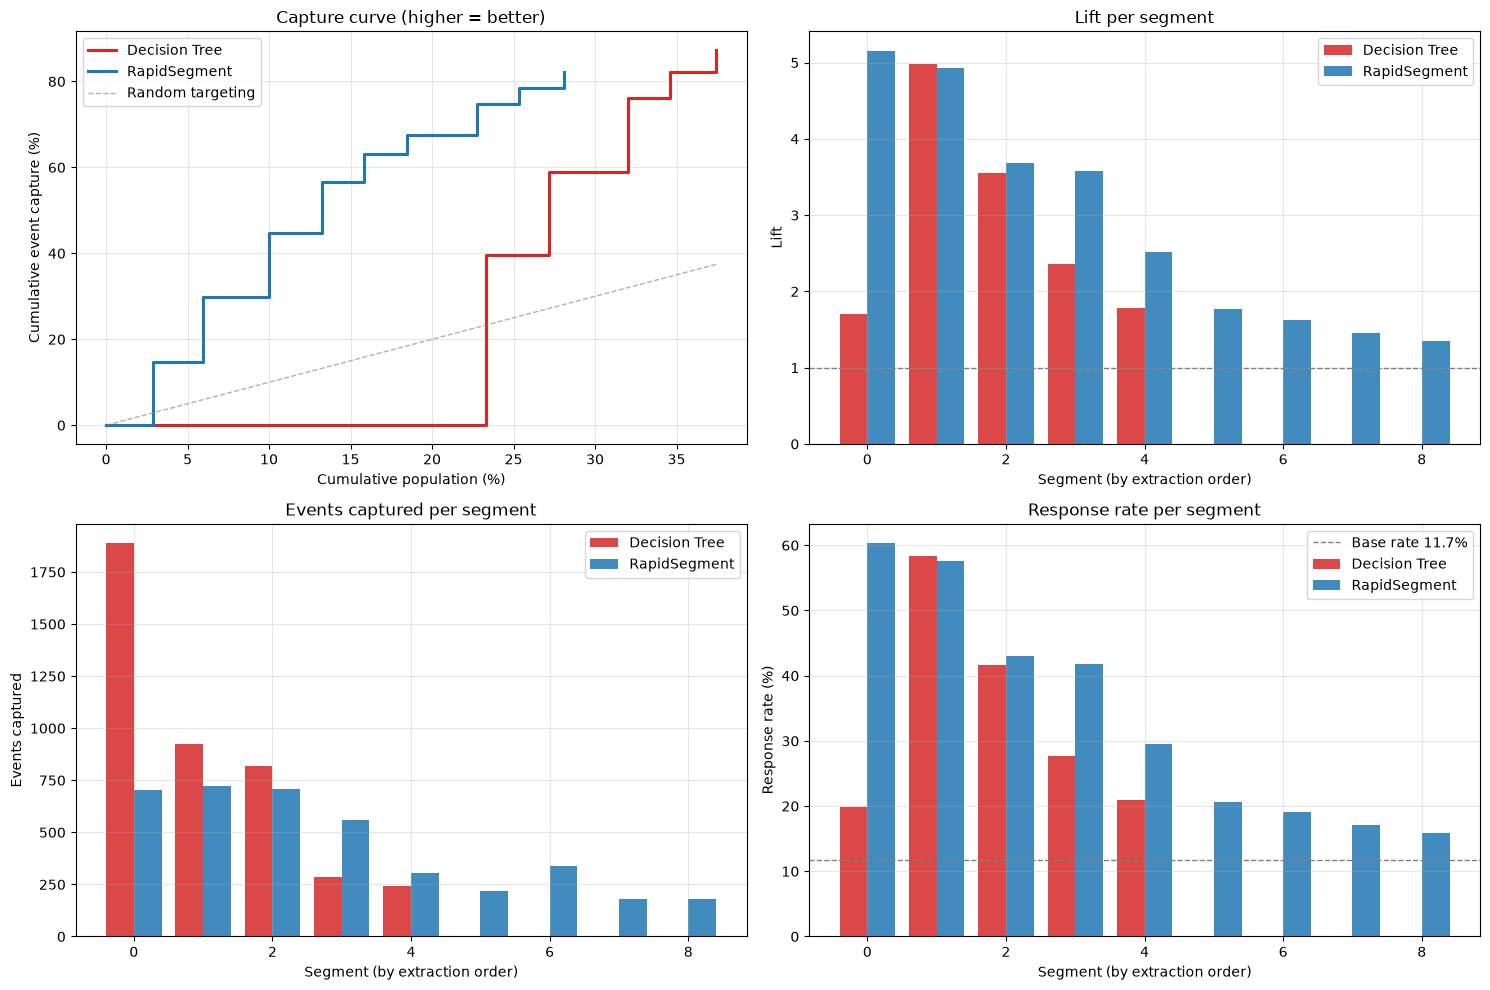

In [8]:
rs_cum_pop = [0] + [r["cum_popcap_pct"] for r in rs_rows]
rs_cum_ev  = [0] + [r["cum_evcap_pct"] for r in rs_rows]
dt_cum_pop = [0] + [r["cum_popcap_pct"] for r in dt_rows]
dt_cum_ev  = [0] + [r["cum_evcap_pct"] for r in dt_rows]

x_idx = np.arange(max(len(rs_rows), len(dt_rows), 1))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.step(dt_cum_pop, dt_cum_ev, where="post", color="#d62728", lw=2.2, label="Decision Tree")
ax.step(rs_cum_pop, rs_cum_ev, where="post", color="#1f77b4", lw=2.2, label="RapidSegment")
ax.plot(dt_cum_pop, dt_cum_pop, "--", color="gray", lw=1, alpha=.6, label="Random targeting")
ax.set_xlabel("Cumulative population (%)"); ax.set_ylabel("Cumulative event capture (%)")
ax.set_title("Capture curve (higher = better)"); ax.legend(); ax.grid(alpha=.3)

ax = axes[0, 1]
ax.bar(x_idx[:len(dt_rows)] - 0.2, [r["lift"] for r in dt_rows], width=0.4,
       color="#d62728", alpha=.85, label="Decision Tree")
ax.bar(x_idx[:len(rs_rows)] + 0.2, [r["lift"] for r in rs_rows], width=0.4,
       color="#1f77b4", alpha=.85, label="RapidSegment")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Segment (by extraction order)"); ax.set_ylabel("Lift")
ax.set_title("Lift per segment"); ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 0]
ax.bar(x_idx[:len(dt_rows)] - 0.2, [r["events"] for r in dt_rows], width=0.4,
       color="#d62728", alpha=.85, label="Decision Tree")
ax.bar(x_idx[:len(rs_rows)] + 0.2, [r["events"] for r in rs_rows], width=0.4,
       color="#1f77b4", alpha=.85, label="RapidSegment")
ax.set_xlabel("Segment (by extraction order)"); ax.set_ylabel("Events captured")
ax.set_title("Events captured per segment"); ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 1]
ax.bar(x_idx[:len(dt_rows)] - 0.2, [r["response_rate"] for r in dt_rows], width=0.4,
       color="#d62728", alpha=.85, label="Decision Tree")
ax.bar(x_idx[:len(rs_rows)] + 0.2, [r["response_rate"] for r in rs_rows], width=0.4,
       color="#1f77b4", alpha=.85, label="RapidSegment")
ax.axhline(base_rate, color="gray", ls="--", lw=1, label=f"Base rate {base_rate:.1f}%")
ax.set_xlabel("Segment (by extraction order)"); ax.set_ylabel("Response rate (%)")
ax.set_title("Response rate per segment"); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

## 6. Rule highlights

In [9]:
print("TOP 3 RapidSegment rules (by lift):")
for r in sorted(rs_rows, key=lambda r: r["lift"], reverse=True)[:3]:
    print(f"  lift={r['lift']:.2f}  events={r['events']:>4}  count={r['count']:>5,}")
    print(f"    {r['rule']}")

print("\nTOP 3 Decision Tree rules (by lift):")
for r in sorted(dt_rows, key=lambda r: r["lift"], reverse=True)[:3]:
    print(f"  lift={r['lift']:.2f}  events={r['events']:>4}  count={r['count']:>5,}")
    print(f"    {r['rule']}")

TOP 3 RapidSegment rules (by lift):
  lift=5.15  events= 701  count=1,163
    housing=[no] & pdays=[8.50, 197.50) & poutcome=[other, success]
  lift=4.93  events= 723  count=1,254
    contact=[cellular] & duration=[702.50, inf) & previous=(-inf, 0.50)
  lift=3.68  events= 707  count=1,643
    duration=[613.50, inf) & loan=[no]

TOP 3 Decision Tree rules (by lift):
  lift=4.99  events= 922  count=1,580
    duration > 836.5
  lift=3.56  events= 819  count=1,969
    duration > 503.5 & contact IN (cellular)
  lift=2.36  events= 285  count=1,032
    duration > 88.5 & poutcome IN (failure, other, success) & housing IN (no)


## 7. How to use this notebook on your own data

1. Edit the **USER CONFIG** cell:
   - `DATA_PATH` — path to your csv / parquet / arrow / feather / xlsx file
   - `TARGET` — target column name (`None` to auto-detect)
   - `POSITIVE` — positive-class value if the target is not already 0/1
   - `IGNORE_COLUMNS` — list of columns both models should ignore (IDs, PII, leakage)
2. Optionally tune RapidSegment (`RS_*`) and Decision Tree (`DT_*`) knobs.
3. Run all cells.

**CLI equivalent** (same options, headless-friendly):

```bash
python3 Examples/compare_segmenters_general.py \
    --data path/to/data.csv \
    --target Response --positive yes \
    --ignore-columns id customer_id \
    --plot-out comparison.png --report-out comparison.md
```